In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap

In [2]:
# Read in data, here the top scores for each protein/TRN pair (top RFI)
df = pd.read_csv('data/top_protein_trn_score_matrix.csv',index_col=0)

In [3]:
# Sort values within each row from highest to lowest
sorted_values = np.sort(df.to_numpy(dtype=float), axis=1)[:, ::-1]

# Convert the sorted array back into a dataframe
# Rows keep the original protein/index labels
# Columns are renamed by rank rather than original TRN/feature name
df_row_sorted = pd.DataFrame(
    sorted_values,
    index=df.index,
    columns=[f"rank_{i+1}" for i in range(df.shape[1])]
)

# Order proteins by their highest-ranked value
# Highest top score appears first
protein_order = np.argsort(df_row_sorted.iloc[:, 0].to_numpy())[::-1]
df_final = df_row_sorted.iloc[protein_order]

# Count how many zero values each protein has across ranked columns
zero_counts = (df_final == 0).sum(axis=1)

# Remove proteins with more than 100 zero-valued entries
df_final = df_final[zero_counts <= 100]

# Remove ranked columns where more than 75% of proteins have zero values
df_subset = df_final.loc[:, (df_final == 0).mean(axis=0) <= 0.75]

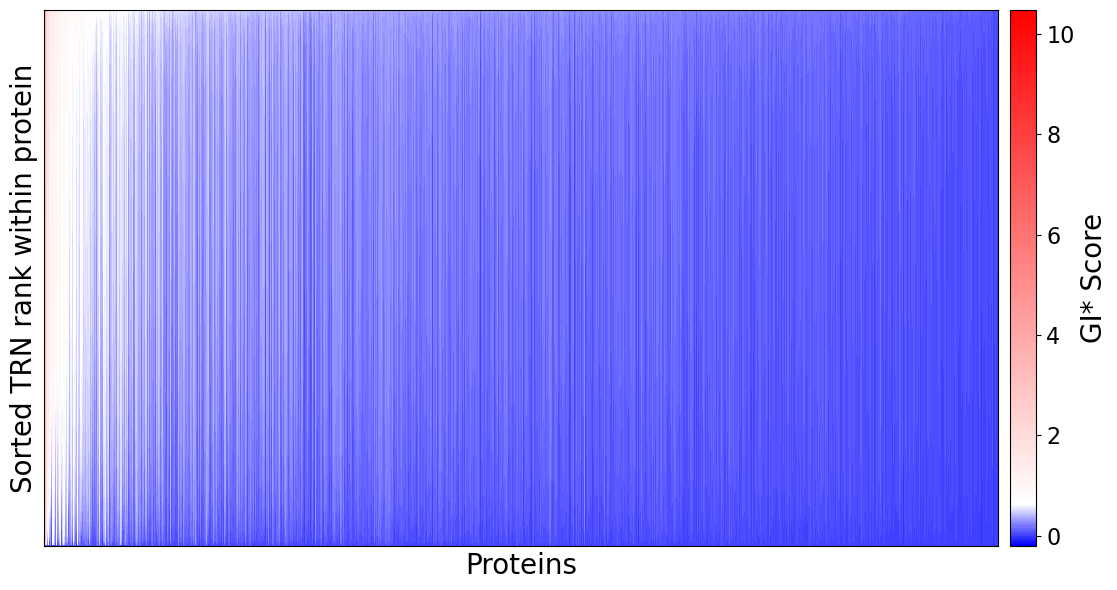

In [4]:
# Create figure for heatmap
plt.figure(figsize=(12, 6))

# Convert dataframe to numpy array for plotting
data = df_final.to_numpy()

# Get min and max values for color scaling
vmin = np.nanmin(data)
vmax = np.nanmax(data)

# Define center value (white point in colormap)
vcenter = 0.612

# Compute relative position of the center within the data range
p = (vcenter - vmin) / (vmax - vmin)

# Ensure the position stays within valid bounds [0, 1]
p = np.clip(p, 0, 1)

# Create a custom blue–white–red colormap
# White is explicitly positioned at the center value (vcenter)
cmap = LinearSegmentedColormap.from_list(
    "custom_bwr",
    [
        (0.0, "blue"),
        (p, "white"),
        (1.0, "red"),
    ]
)

# Normalize values to map onto the colormap range
norm = Normalize(vmin=vmin, vmax=vmax)

# Plot heatmap
# Transpose so rows = TRN rank and columns = proteins
im = plt.imshow(
    df_subset.T,
    aspect='auto',
    cmap=cmap,
    norm=norm,
    interpolation='nearest'
)

# Add colorbar with label and formatting
cbar = plt.colorbar(im, label='GI* Score', pad=0.01)
cbar.set_label(label='GI* Score', fontsize=20)
cbar.ax.tick_params(labelsize=16)

# Set axis labels
plt.xlabel('Proteins', fontsize=20)
plt.ylabel('Sorted TRN rank within protein', fontsize=20)

# Remove tick labels for cleaner visualization
plt.xticks([])
plt.yticks([])

# Show plot
plt.tight_layout()
plt.show()

In [5]:
# Select the top 10% of proteins based on the sorted ordering in df_final
top10 = df_final.head(int(len(df_final) * 0.10))

# Select the top 10% from the filtered subset (after column filtering)
top10sub = df_subset.head(int(len(df_subset) * 0.10))

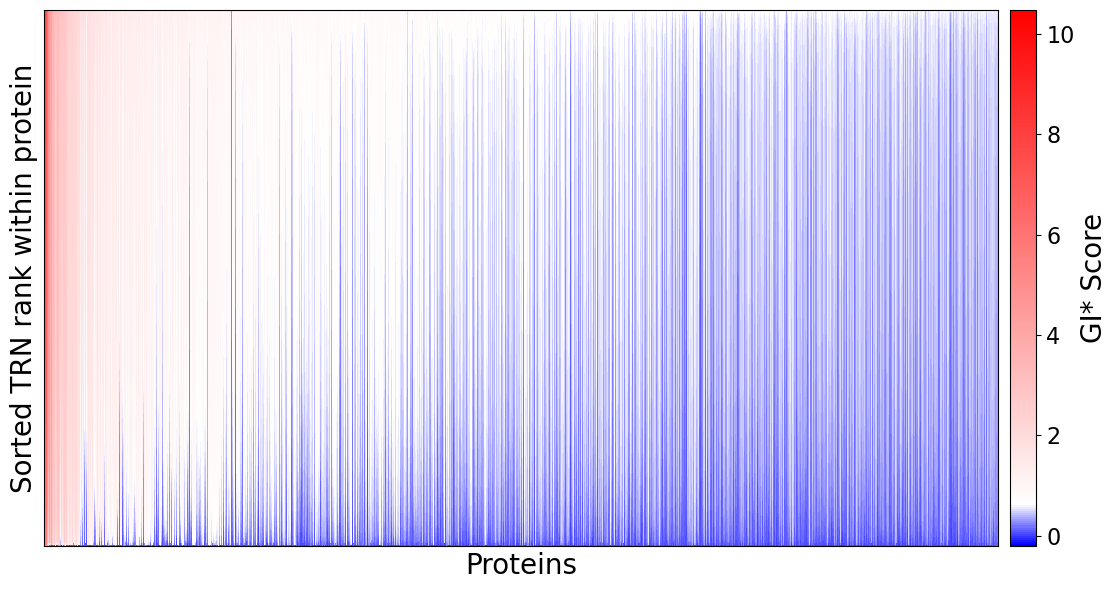

In [6]:
# Create figure for heatmap of top 10% proteins (subset version)
plt.figure(figsize=(12, 6))

# Use full dataset to define consistent color scaling
data = df_final.to_numpy()
vmin = np.nanmin(data)
vmax = np.nanmax(data)

# Define center value for colormap (white point)
vcenter = 0.612

# Compute relative position of center within the data range
p = (vcenter - vmin) / (vmax - vmin)

# Ensure position is within valid range
p = np.clip(p, 0, 1)

# Create custom blue–white–red colormap with white at vcenter
cmap = LinearSegmentedColormap.from_list(
    "custom_bwr",
    [
        (0.0, "blue"),
        (p, "white"),
        (1.0, "red"),
    ]
)

# Normalize values across full data range for comparability
norm = Normalize(vmin=vmin, vmax=vmax)

# Plot heatmap using only top 10% subset
# Transpose so rows = TRN rank and columns = proteins
im = plt.imshow(
    top10sub.T,
    aspect='auto',
    cmap=cmap,
    norm=norm,
    interpolation='nearest'
)

# Add colorbar with label and formatting
cbar = plt.colorbar(im, label='GI* Score', pad=0.01)
cbar.set_label(label='GI* Score', fontsize=20)
cbar.ax.tick_params(labelsize=16)

# Set axis labels
plt.xlabel('Proteins', fontsize=20)
plt.ylabel('Sorted TRN rank within protein', fontsize=20)

# Remove tick labels for cleaner visualization
plt.xticks([])
plt.yticks([])

# Show plot
plt.tight_layout()
plt.show()